In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore, f_oneway
import warnings
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import TargetEncoder, OneHotEncoder
from sklearn.impute import KNNImputer
from scipy.stats import chi2_contingency


warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [3]:
df = pd.read_csv('../trabajo_final/data/income_data.csv')

# Data Preview

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              48842 non-null  int64
 1   workclass        48842 non-null  str  
 2   fnlwgt           48842 non-null  int64
 3   education        48842 non-null  str  
 4   educational-num  48842 non-null  int64
 5   marital-status   48842 non-null  str  
 6   occupation       48842 non-null  str  
 7   relationship     48842 non-null  str  
 8   race             48842 non-null  str  
 9   gender           48842 non-null  str  
 10  capital-gain     48842 non-null  int64
 11  capital-loss     48842 non-null  int64
 12  hours-per-week   48842 non-null  int64
 13  native-country   48842 non-null  str  
 14  income           48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB


In [5]:
df.head(10)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
6,29,?,227026,HS-grad,9,Never-married,?,Unmarried,Black,Male,0,0,40,United-States,<=50K
7,63,Self-emp-not-inc,104626,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,3103,0,32,United-States,>50K
8,24,Private,369667,Some-college,10,Never-married,Other-service,Unmarried,White,Female,0,0,40,United-States,<=50K
9,55,Private,104996,7th-8th,4,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,10,United-States,<=50K


La variable objetivo es income

In [6]:
df.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [7]:
num_cols = df.select_dtypes(include=['number']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(num_cols)
print(cat_cols)

['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']
['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country', 'income']


# Hipotesis

1. Educación: A mayor nivel educativo, es mayor el ingreso de superar los 50K
2. Edad: Los ingresos tienden a subir con la edad, en relacion con la experiencia
3. Horas semanales: Los que trabajan mas de 40h estan mas en la parte de ingresos mayores a 50K
4. Sexo: El sexo influye en el ingreso
5. Estado civil: Las personas casadas tienen mas ingresos por su estabilidad

### Educación

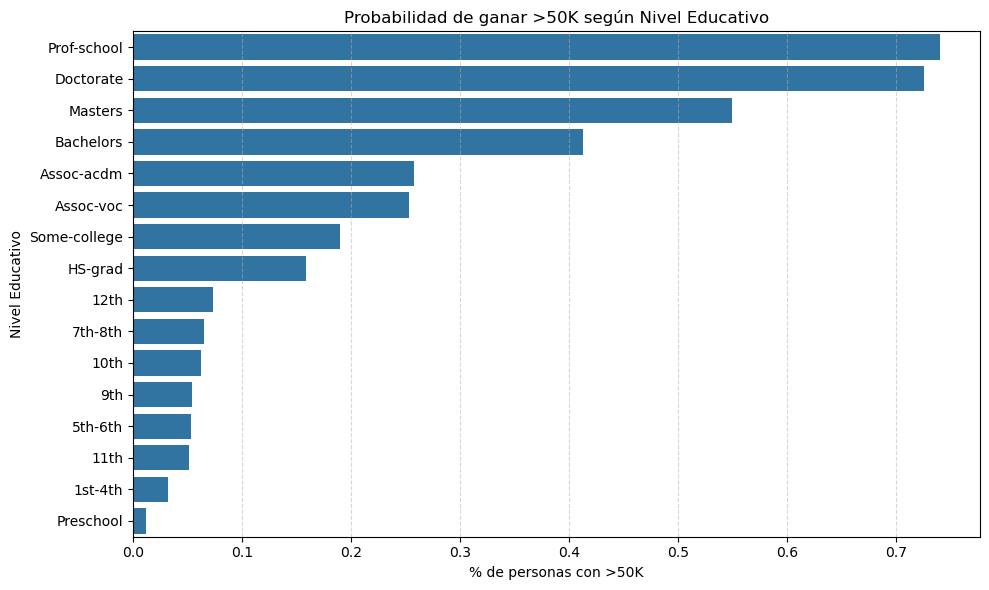

In [28]:
# Convertimos el income a numérico
df['income_bin'] = (df['income'] == '>50K').astype(int)

# Agrupamos y ordenamos
edu_prob = df.groupby('education')['income_bin'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=edu_prob, x='income_bin', y='education')

plt.title('Probabilidad de ganar >50K según Nivel Educativo')
plt.xlabel('% de personas con >50K')
plt.ylabel('Nivel Educativo')
plt.grid(axis='x', linestyle='--', alpha=0.5) # Líneas de guía verticales
plt.tight_layout() # Ajusta los márgenes automáticamente
plt.show()

Podemos ver que la hipotesis se cumple, porque vemos un crecimiento en proporcional del nivel educativo con los que ganan mas de 50K

### Edad

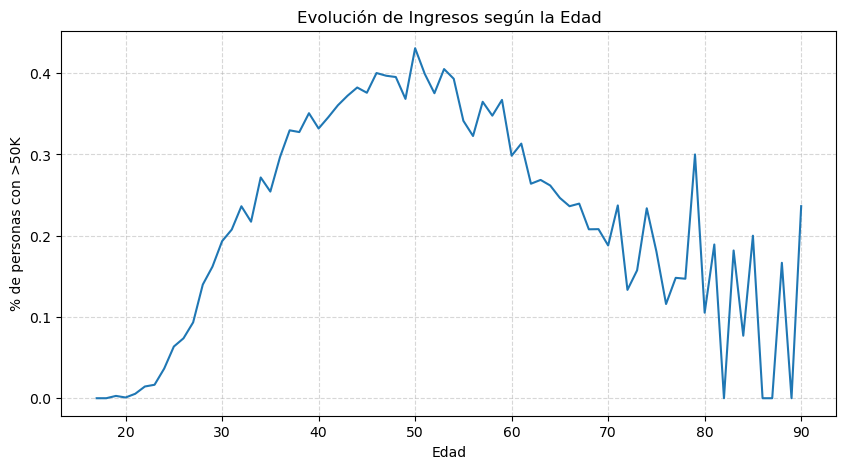

In [9]:
# Agrupamos por edad para ver la tendencia
age_trend = df.groupby('age')['income_bin'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=age_trend, x='age', y='income_bin')
plt.title('Evolución de Ingresos según la Edad')
plt.ylabel('% de personas con >50K')
plt.xlabel('Edad')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Esta hipotesis se acepta durante un periodo de tiempo, luego vemos que la grafica baja, porque la gente se va jubilando, entonces tiene menos ingresos

### Horas semanales

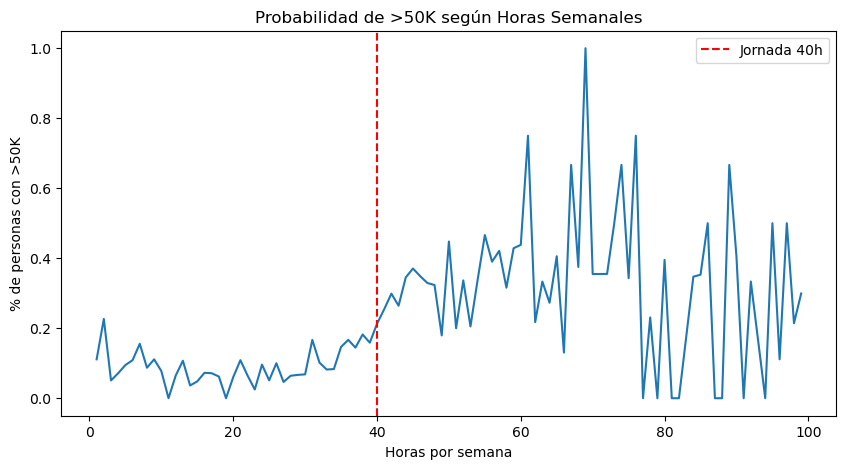

In [10]:
# Hecho por IA
# Agrupamos por horas para calcular el % de personas con >50K
hours_trend = df.groupby('hours-per-week')['income_bin'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=hours_trend, x='hours-per-week', y='income_bin')

# Añadimos una línea vertical en las 40h para marcar la referencia
plt.axvline(40, color='red', linestyle='--', label='Jornada 40h')

plt.title('Probabilidad de >50K según Horas Semanales')
plt.ylabel('% de personas con >50K')
plt.xlabel('Horas por semana')
plt.legend()
plt.show()

Confirmamos la hipotesis, existe una relacion directa entre las horas trabajadas y los ingresos

### Sexo

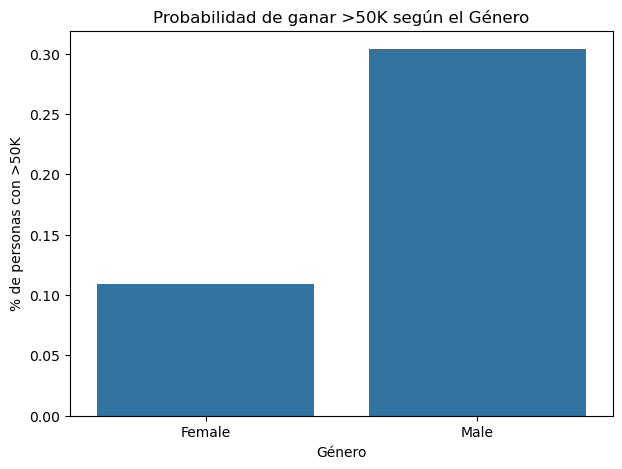

In [11]:
# Calculamos la probabilidad de ingresos altos por género
gender_trend = df.groupby('gender')['income_bin'].mean().reset_index()

# 2. Graficamos
plt.figure(figsize=(7, 5))
sns.barplot(data=gender_trend, x='gender', y='income_bin')

plt.title('Probabilidad de ganar >50K según el Género')
plt.ylabel('% de personas con >50K')
plt.xlabel('Género')
plt.show()

La hipotesis se confirma, podemos ver que existe una brecha entre el sexo de los trabajadores, para ganar mas ingresos

### Estado civil

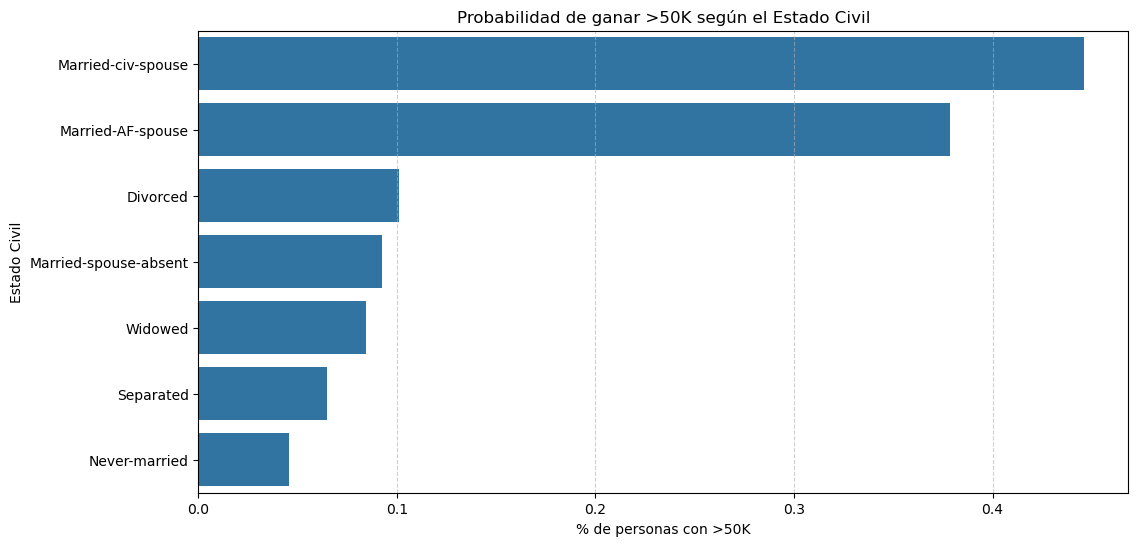

In [12]:
# Calculamos la probabilidad de ingresos altos por estado civil
marital_trend = df.groupby('marital-status')['income_bin'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=marital_trend, x='income_bin', y='marital-status')

plt.title('Probabilidad de ganar >50K según el Estado Civil')
plt.xlabel('% de personas con >50K')
plt.ylabel('Estado Civil')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

La hipotesis se vuelve a confirmar, las personas casadas son las que tienen mas ingresos. Tambien es cierto que esto tiene que ver con la edad, y como hemos visto en la hipotesis de la edad, la gente que tiene mas probabilidades de tener mas ingresos son los de 50 años. Y a esta edad estas casado normalmente

### Conclusiones:
1. 

# Análisis Univariado

### Estadistica descriptiva

In [53]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.643585,13.710510,17.000000,28.000000,37.00000,48.000000,9.000000e+01
fnlwgt,48842.0,189664.134597,105604.025423,12285.000000,117550.500000,178144.50000,237642.000000,1.490400e+06
educational-num,48842.0,10.078089,2.570973,1.000000,9.000000,10.00000,12.000000,1.600000e+01
capital-gain,48842.0,1079.067626,7452.019058,0.000000,0.000000,0.00000,0.000000,9.999900e+04
capital-loss,48842.0,87.502314,403.004552,0.000000,0.000000,0.00000,0.000000,4.356000e+03
hours-per-week,48842.0,40.422382,12.391444,1.000000,40.000000,40.00000,45.000000,9.900000e+01
income_bin,48842.0,0.239282,0.426649,0.000000,0.000000,0.00000,0.000000,1.000000e+00
capital-gain-log,48842.0,0.728544,2.445480,0.000000,0.000000,0.00000,0.000000,1.151293e+01
capital-loss-log,48842.0,0.350973,1.586232,0.000000,0.000000,0.00000,0.000000,8.379539e+00
fnlwgt_log,48842.0,11.982950,0.630823,9.416134,11.674623,12.09035,12.378521,1.421456e+01


In [55]:
# Calcular moda
df.mode().T

,0
age,36
workclass,Private
fnlwgt,203488
education,HS-grad
educational-num,9
marital-status,Married-civ-spouse
occupation,Prof-specialty
relationship,Husband
race,White
gender,Male


In [59]:
# Calcular IQR
df.describe().T["75%"] - df.describe().T["25%"]

age                     20.000000
fnlwgt              120091.500000
educational-num          3.000000
capital-gain             0.000000
capital-loss             0.000000
hours-per-week           5.000000
income_bin               0.000000
capital-gain-log         0.000000
capital-loss-log         0.000000
fnlwgt_log               0.703897
dtype: float64

In [60]:
# Calcular rango
df.describe().T["max"] - df.describe().T["min"]

age                 7.300000e+01
fnlwgt              1.478115e+06
educational-num     1.500000e+01
capital-gain        9.999900e+04
capital-loss        4.356000e+03
hours-per-week      9.800000e+01
income_bin          1.000000e+00
capital-gain-log    1.151293e+01
capital-loss-log    8.379539e+00
fnlwgt_log          4.798421e+00
dtype: float64

In [62]:
# Almacenar columnas numéricas para evitar error
num_columns = df.describe().columns
num_columns

Index(['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week', 'income_bin', 'capital-gain-log', 'capital-loss-log',
       'fnlwgt_log'],
      dtype='str')

In [64]:
# Calcular asimetría
"""
valor > 0 -> distribución asimétrica a la derecha
valor = 0 -> distribución simétrica
valor < 0 -> distribución asimétrica a la izquierda
"""
df[num_columns].skew()

age                  0.557580
fnlwgt               1.438892
educational-num     -0.316525
capital-gain        11.894659
capital-loss         4.569809
hours-per-week       0.238750
income_bin           1.222216
capital-gain-log     3.113630
capital-loss-log     4.302960
fnlwgt_log          -0.836323
dtype: float64

In [66]:
# Calcular la curtosis
"""
valor > 0 -> distribución leptocúrtica
valor = 0 -> distribución mesocúrtica
valor < 0 -> distribución platicúrtica
"""
df[num_columns].kurt()

age                  -0.184269
fnlwgt                6.057848
educational-num       0.625745
capital-gain        152.693096
capital-loss         20.014346
hours-per-week        2.951059
income_bin           -0.506208
capital-gain-log      7.908558
capital-loss-log     16.535724
fnlwgt_log            0.820971
dtype: float64

### Columnas númericas

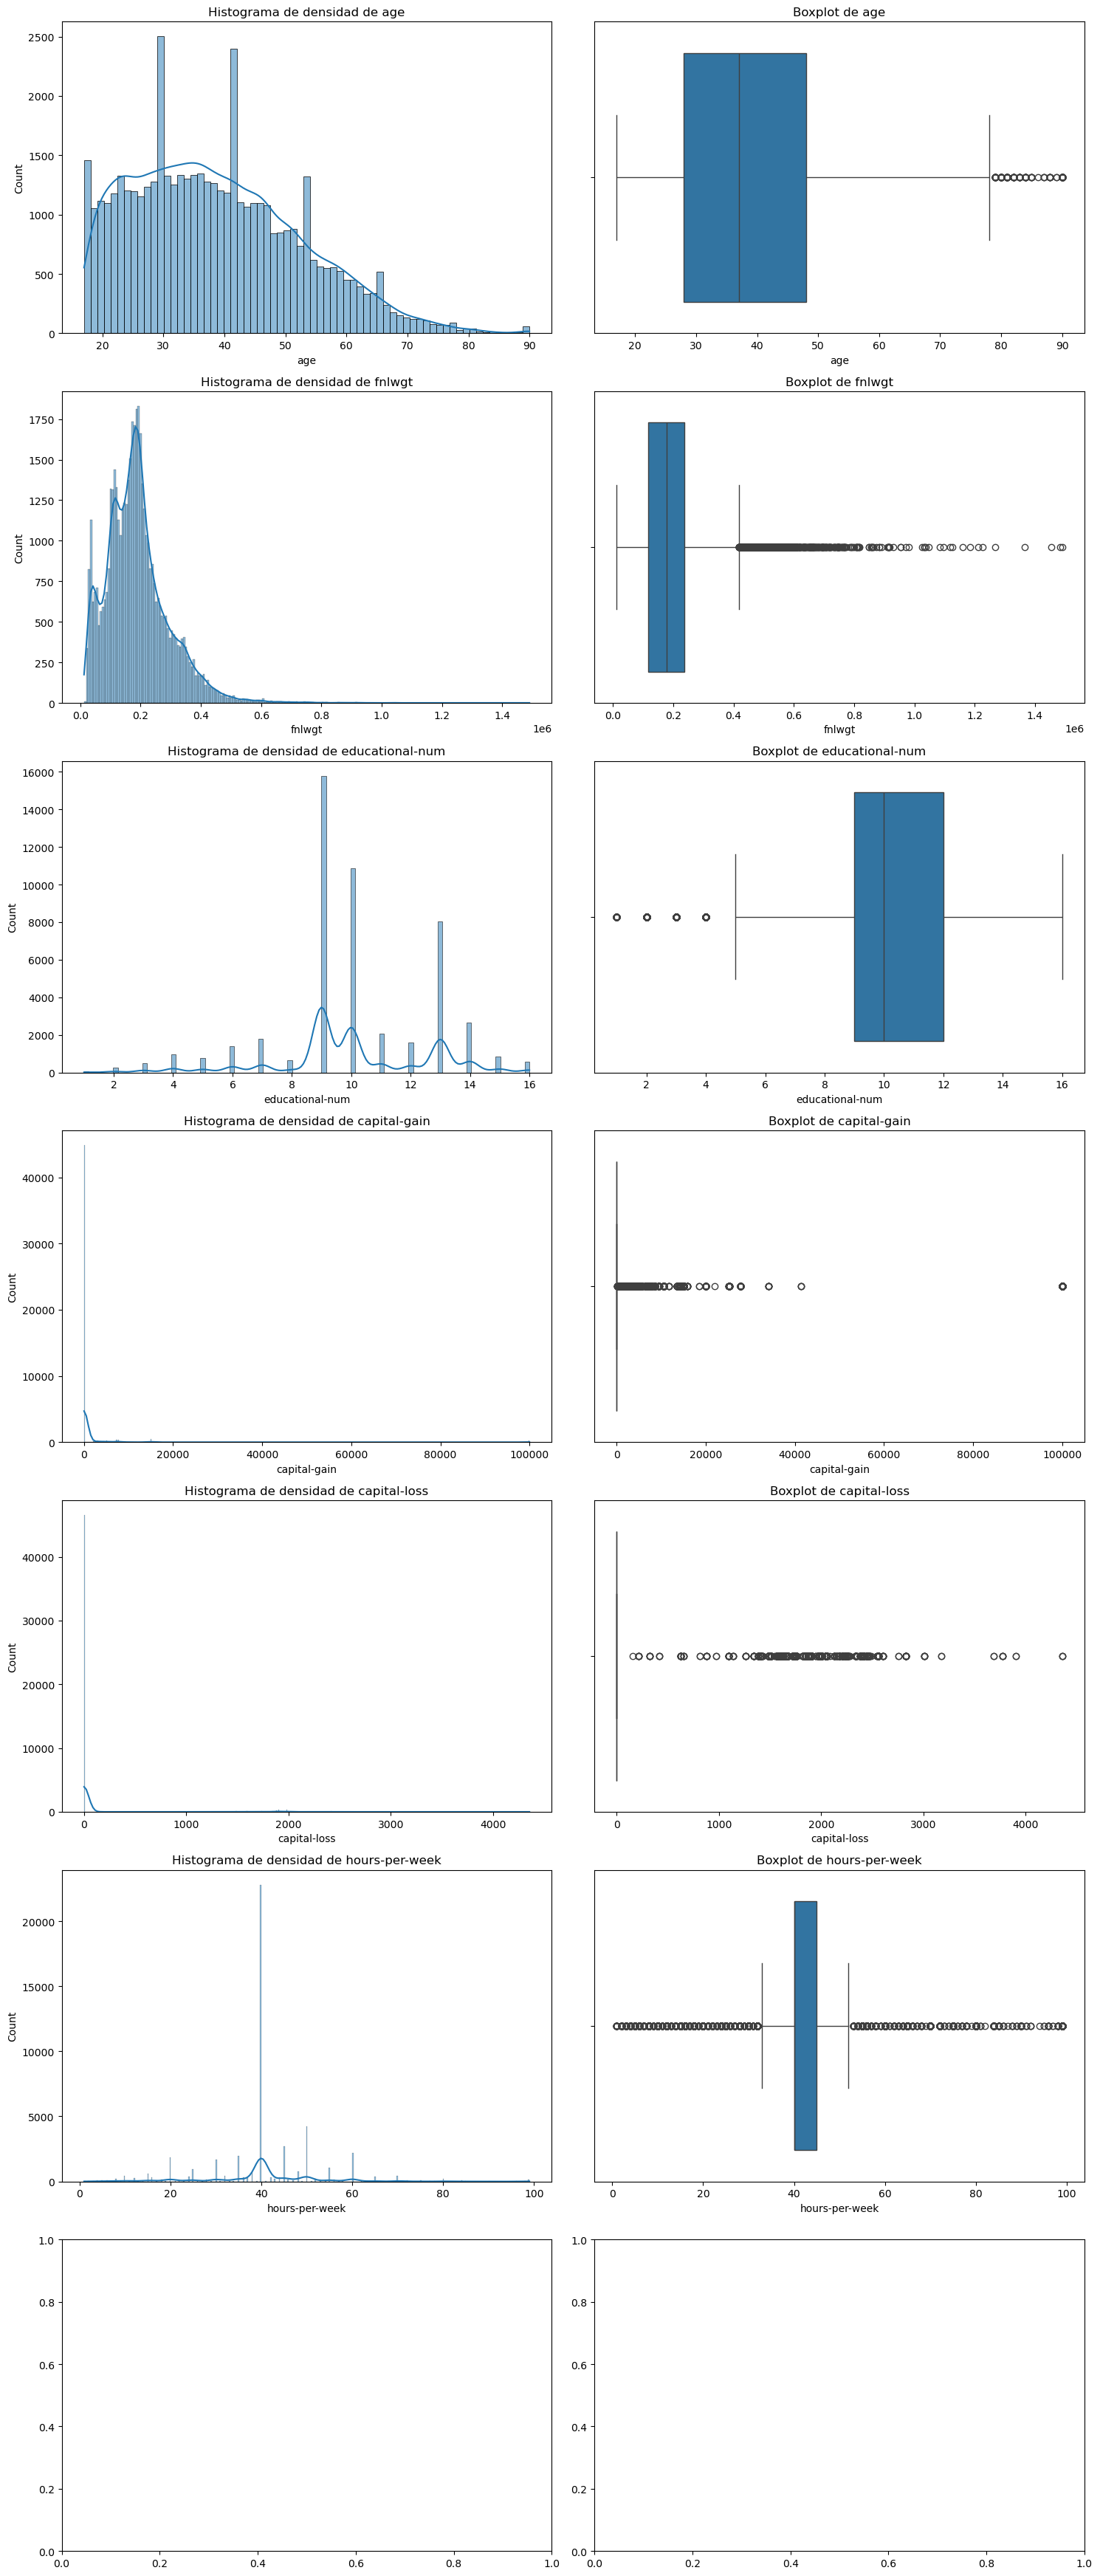

In [13]:
fig, axes = plt.subplots(nrows=len(df.select_dtypes(include=[np.number]).columns), ncols=2, figsize=(15, 5 * len(df.select_dtypes(include=[np.number]).columns)))

for i, column in enumerate(df[num_cols]):
    # Histograma de densidad
    sns.histplot(df[column], kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'Histograma de densidad de {column}')
    
    # Boxplot
    sns.boxplot(x=df[column], ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot de {column}')

plt.tight_layout()
plt.show()

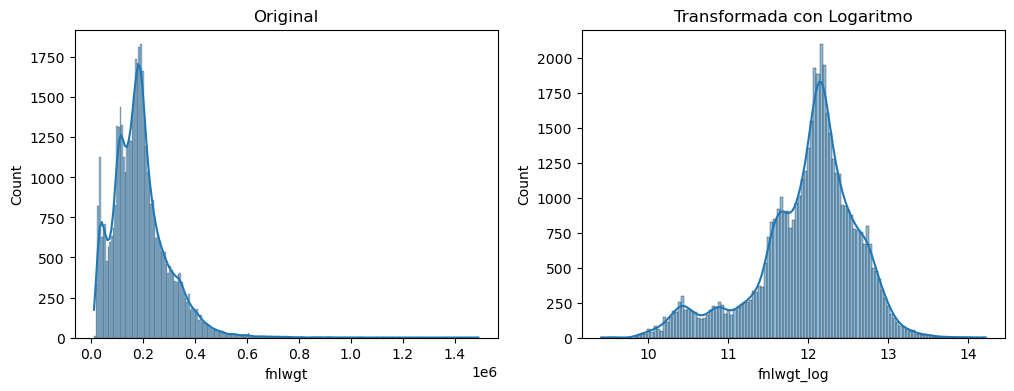

In [22]:
# Aplicamos el logaritmo
df['fnlwgt_log'] = np.log(df['fnlwgt'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['fnlwgt'], kde=True, ax=axes[0])
axes[0].set_title('Original')

sns.histplot(df['fnlwgt_log'], kde=True, ax=axes[1])
axes[1].set_title('Transformada con Logaritmo')

plt.show()

La variable fnlwgt la eliminariamos, porque no tiene relacion para poder predecir los ingresos. A parte de que tiene una correlacion casi nula con income

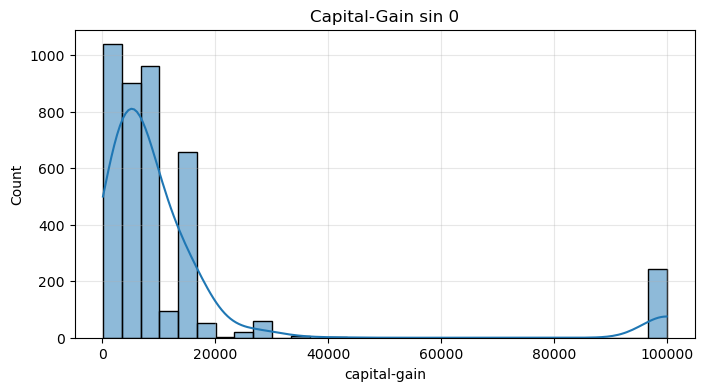

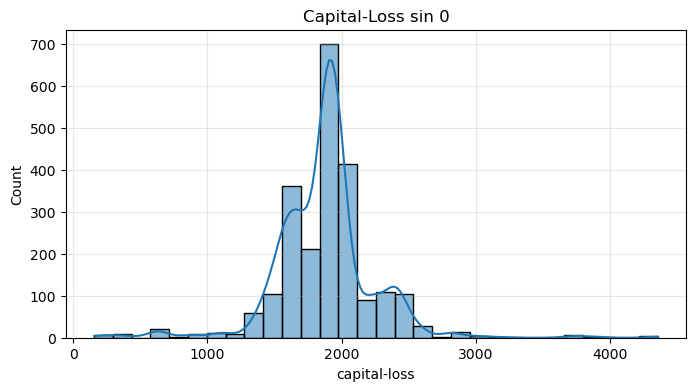

In [15]:
# Filtramos las filas donde los valores sean mayores a 0
gain_no_zero = df[df['capital-gain'] > 0]['capital-gain']
loss_no_zero = df[df['capital-loss'] > 0]['capital-loss']

# Gráfico para capital-gain
plt.subplots(figsize=(8, 4))
sns.histplot(gain_no_zero, bins=30, kde=True)
plt.title('Capital-Gain sin 0')
plt.grid(True, alpha=0.3)
plt.show()

# Gráfico para capital-loss
plt.subplots(figsize=(8, 4))
sns.histplot(loss_no_zero, bins=30, kde=True)
plt.title('Capital-Loss sin 0')
plt.grid(True, alpha=0.3)
plt.show()

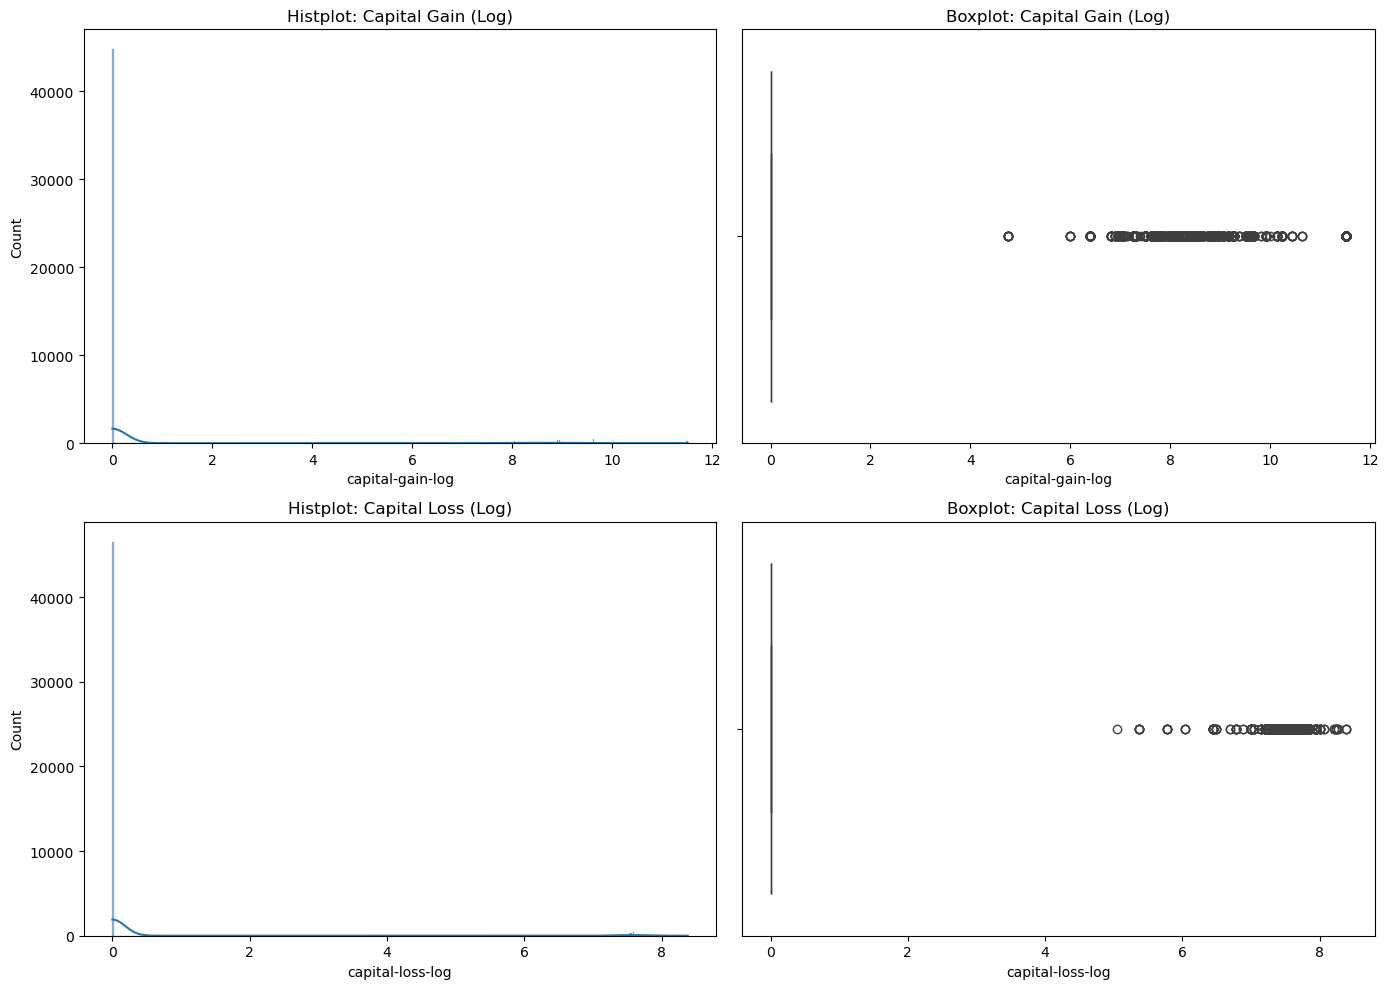

In [19]:
# Aplicar el logaritmo
df['capital-gain-log'] = np.log1p(df['capital-gain'])
df['capital-loss-log'] = np.log1p(df['capital-loss'])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histplot de Capital Gain Log
sns.histplot(df['capital-gain-log'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Histplot: Capital Gain (Log)')

# 2. Boxplot de Capital Gain Log
sns.boxplot(x=df['capital-gain-log'], ax=axes[0, 1])
axes[0, 1].set_title('Boxplot: Capital Gain (Log)')

# 3. Histplot de Capital Loss Log
sns.histplot(df['capital-loss-log'], kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Histplot: Capital Loss (Log)')

# 4. Boxplot de Capital Loss Log
sns.boxplot(x=df['capital-loss-log'], ax=axes[1, 1])
axes[1, 1].set_title('Boxplot: Capital Loss (Log)')

plt.tight_layout()
plt.show()

A lo mejor se pueden binarizar

Podemos ver que en estas dos variables casi todos los regitros los tenemos en 0

In [25]:
df[num_cols].describe(percentiles=[.25, .5, .75, .9, .95, .99]).T.sort_values(by='50%', ascending=False)

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
fnlwgt,48842.0,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,328466.0,379481.65,509484.42,1490400.0
hours-per-week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,55.0,60.00,80.00,99.0
age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,58.0,63.00,74.00,90.0
educational-num,48842.0,10.078089,2.570973,1.0,9.0,10.0,12.0,13.0,14.00,16.00,16.0
capital-gain,48842.0,1079.067626,7452.019058,0.0,0.0,0.0,0.0,0.0,5013.00,15024.00,99999.0
capital-loss,48842.0,87.502314,403.004552,0.0,0.0,0.0,0.0,0.0,0.00,2001.00,4356.0


### Columnas categricas

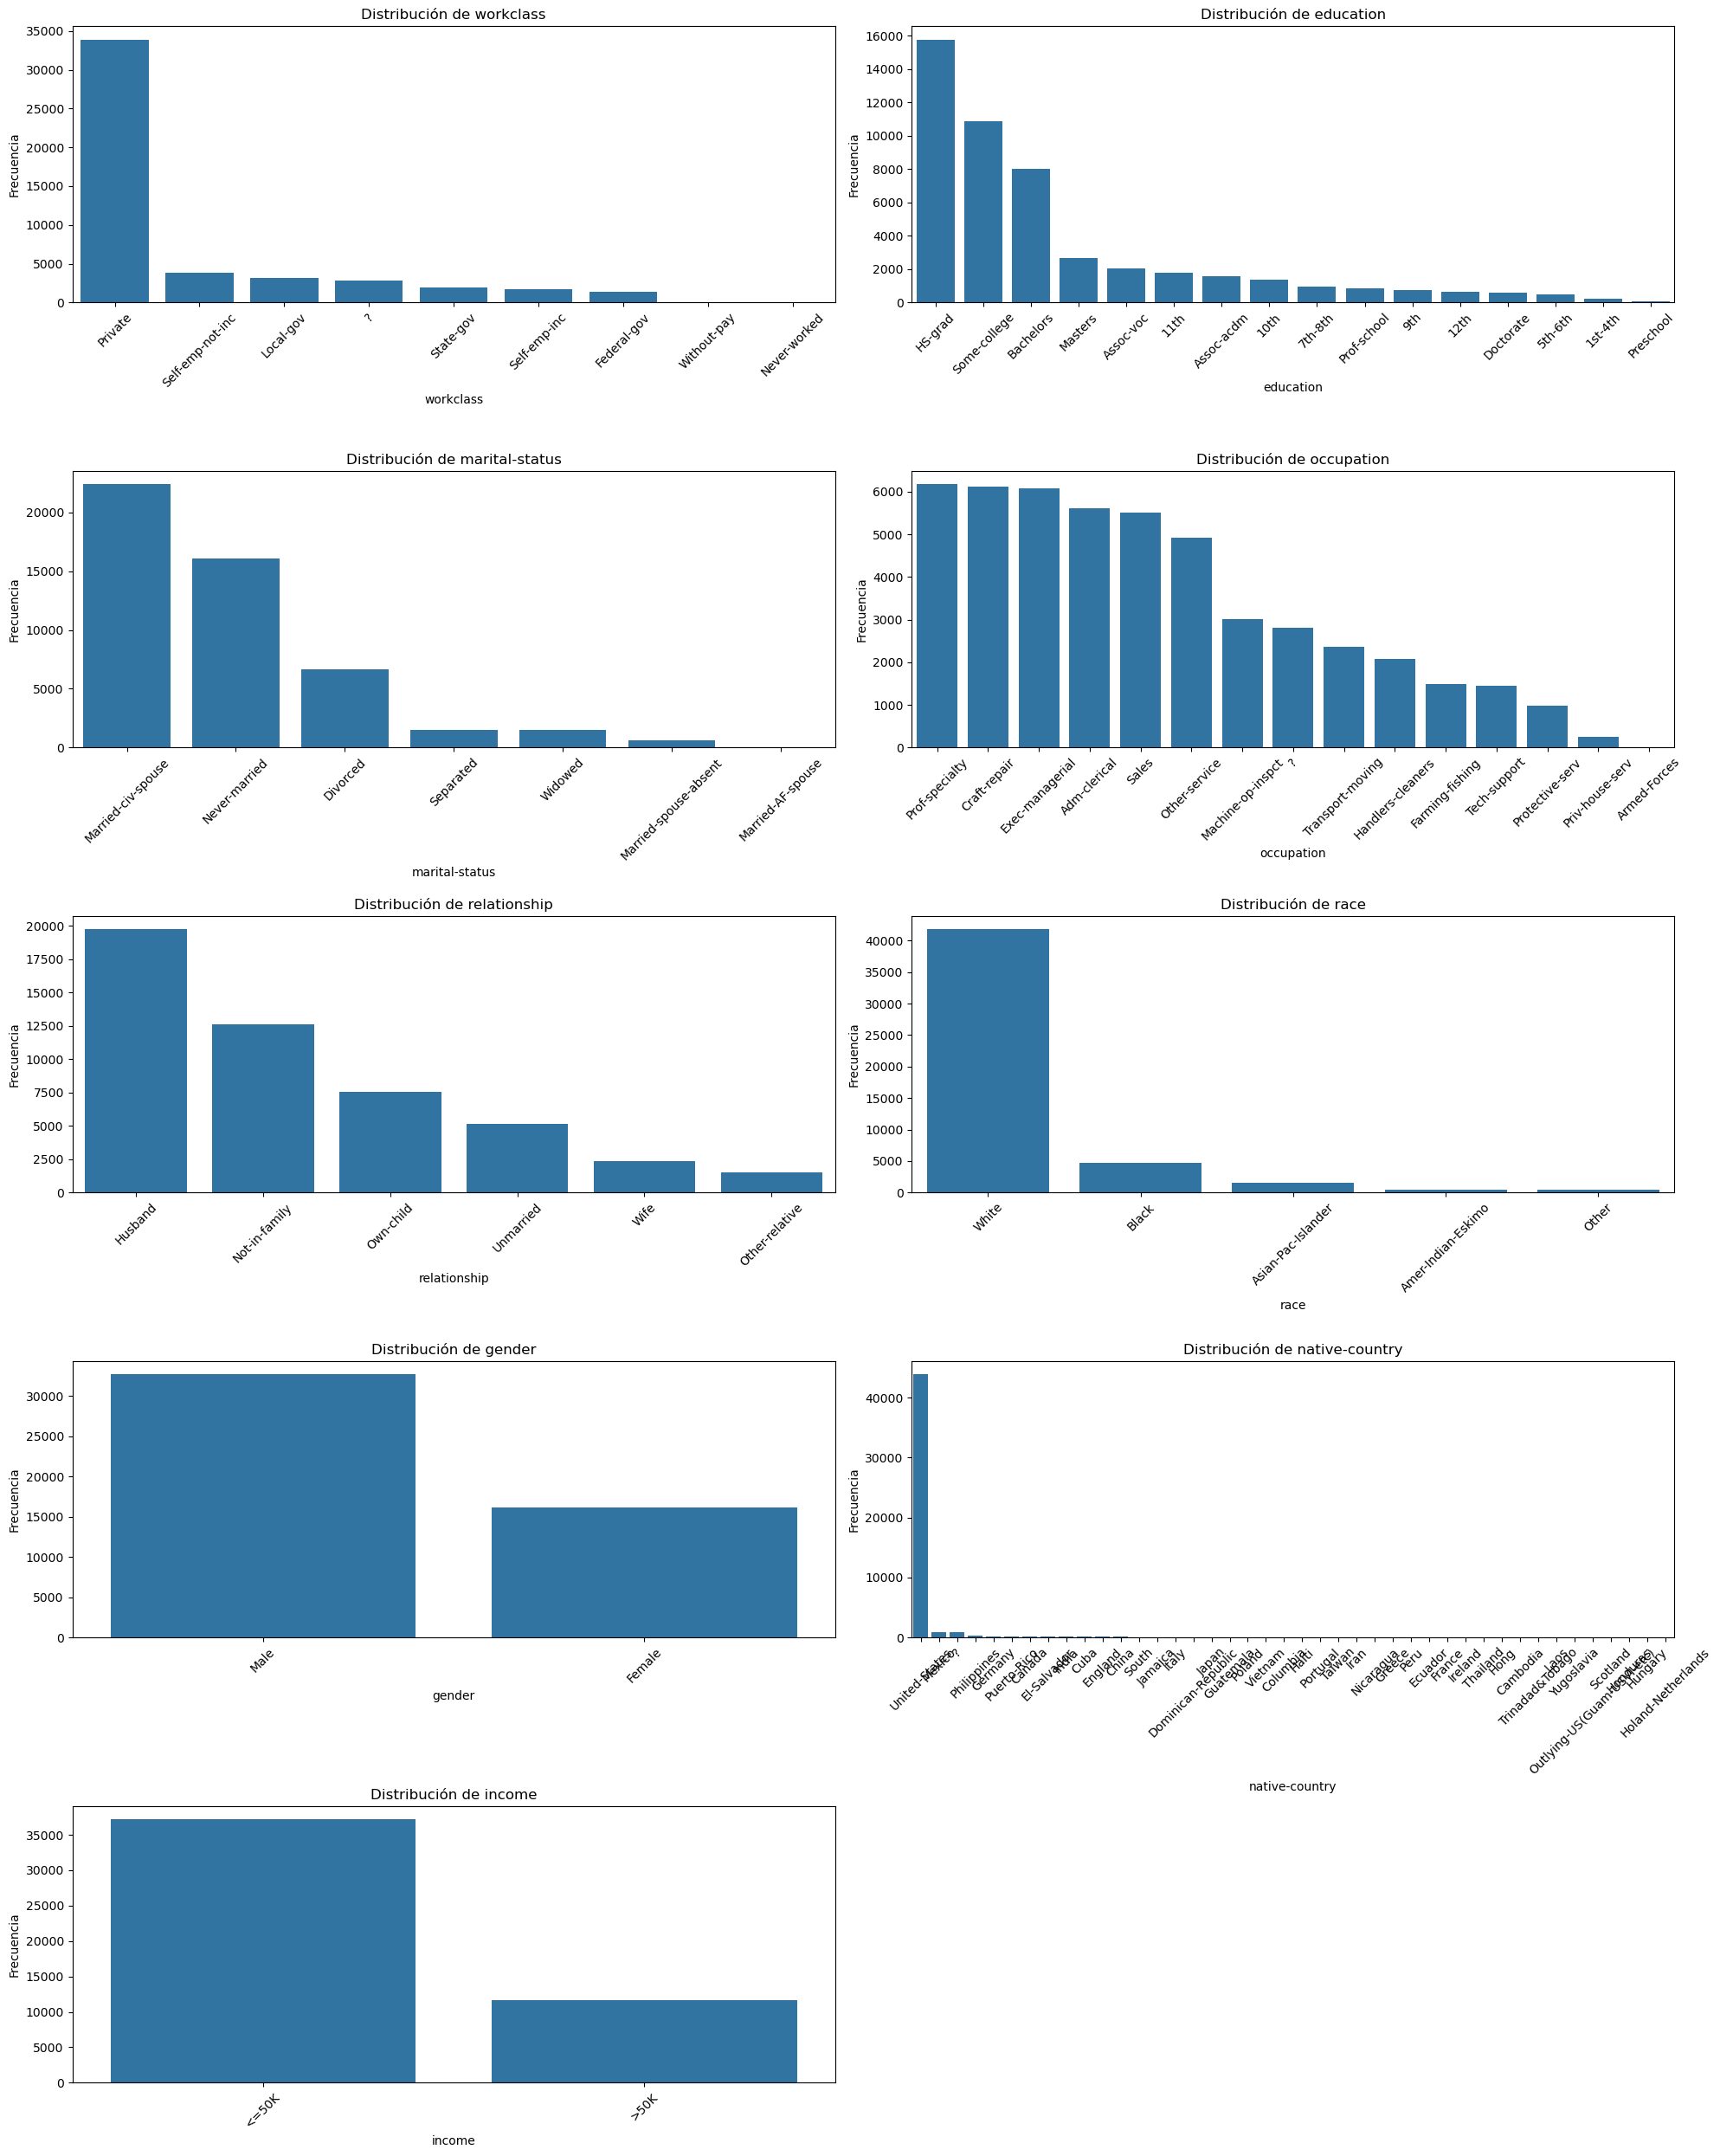

In [26]:
fig, axs = plt.subplots(nrows=len(cat_cols) // 2 + len(cat_cols) % 2, ncols=2, figsize=(20, 5 * (len(cat_cols) // 2 + len(cat_cols) % 2)))

# Aplanar el array de ejes para iterar fácilmente
axs = axs.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, order=df[col].value_counts().index, ax=axs[i])
    axs[i].set_title(f'Distribución de {col}')
    axs[i].set_xlabel(col)
    axs[i].set_ylabel('Frecuencia')
    axs[i].tick_params(axis='x', rotation=45)  # Rotar las etiquetas del eje x para mejor legibilidad

# Eliminar subplots vacíos si el número de columnas es impar
if len(cat_cols) % 2 != 0:
    fig.delaxes(axs[-1])

plt.tight_layout()
plt.show()

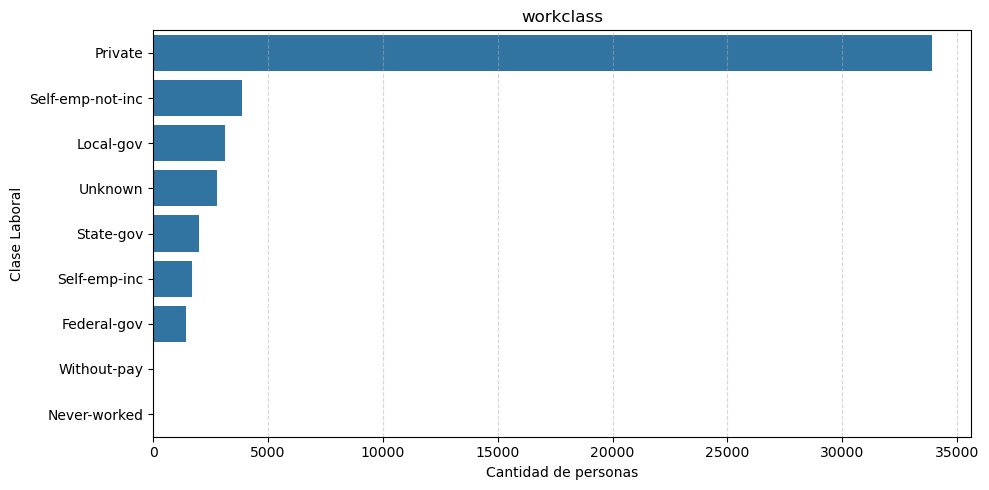

In [31]:
# Reemplazamos los '?' por 'Unknown'
df['workclass'] = df['workclass'].replace('?', 'Unknown')

# Ordenar de mayor a menor frecuencia
order_workclass = df['workclass'].value_counts().index

fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(data=df, y='workclass', order=order_workclass, ax=ax)

plt.title('workclass')
plt.xlabel('Cantidad de personas')
plt.ylabel('Clase Laboral')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

En esta variable podemos hacer un target encoding

Education la podemos eliminar, porque esta educational-num, que es lo mismo, solo que en numeros. Entonces para nuestro modelo nos viene mejor la variable numerica

La variable de estatus hariamos un one hot encoding

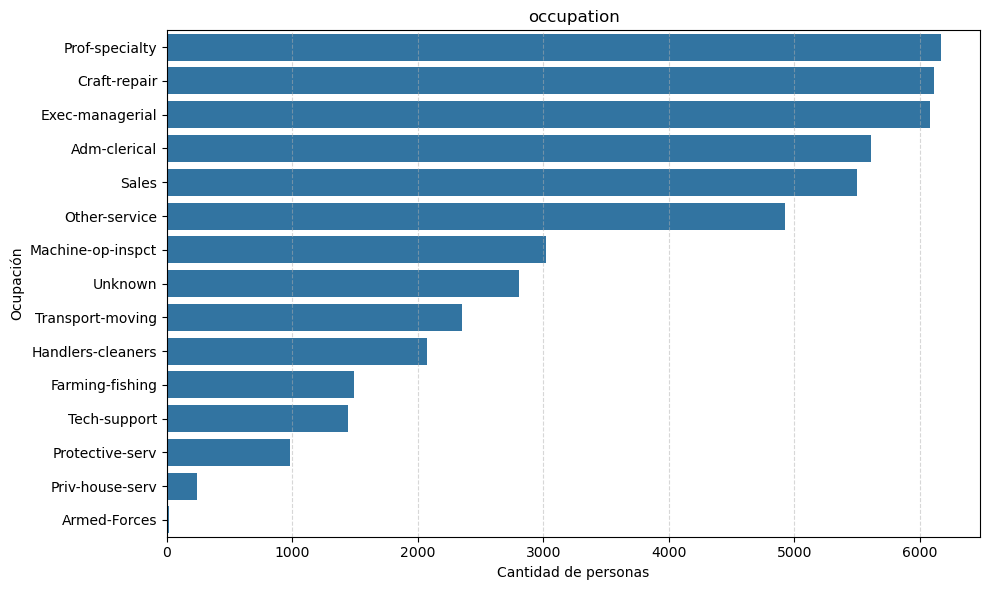

In [33]:
# Cambio
df['occupation'] = df['occupation'].replace('?', 'Unknown')

# Ordenar
order_occupation = df['occupation'].value_counts().index

plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='occupation', order=order_occupation)

plt.title('occupation')
plt.xlabel('Cantidad de personas')
plt.ylabel('Ocupación')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Hemos cambiado la ? por un unknown para que el modelo pueda detectar algunos patrones. Tambien evitamos sesgar los datos, porque no los estamos rellenanado con la moda, y no nos estamos inventando datos.

Podriamos aplicar un target encoding

Relationship one hot encoding

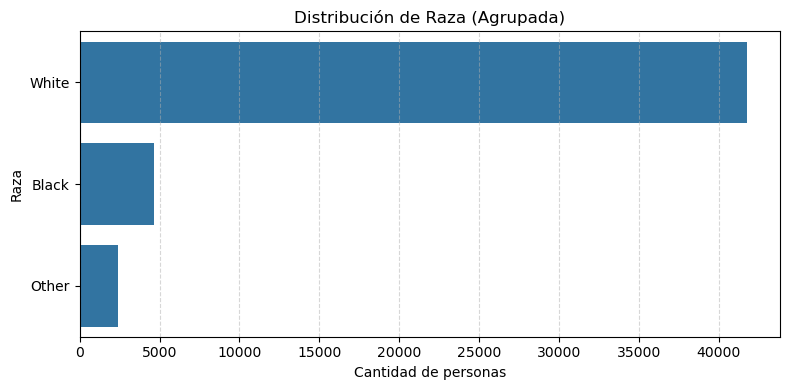

In [ ]:
# El principio con IA
# Agrupamos en White, Black y Other
df["race"] = df["race"].str.strip()
df["race"] = df["race"].apply(
    lambda x: x if x in ["White", "Black"] else "Other"
)

order_race = df["race"].value_counts().index

plt.figure(figsize=(8, 4))
sns.countplot(data=df, y="race", order=order_race)

plt.title("Distribución de Raza (Agrupada)")
plt.xlabel("Cantidad de personas")
plt.ylabel("Raza")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

Como casi todas las personas son del grupo white hemos decidido agrupar esta variable en tres grupos. Asi reducimos el ruido que tenian las minorias

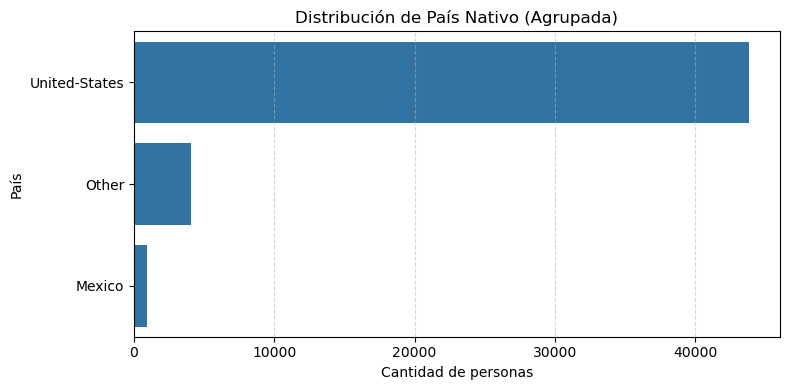

In [ ]:
# Limpiamos espacios en blanco
df['native-country'] = df['native-country'].str.strip()
df['native-country'] = df['native-country'].apply(
    lambda x: x if x in ['United-States', 'Mexico'] else 'Other'
)

plt.figure(figsize=(8, 4))
sns.countplot(data=df, y='native-country', order=df['native-country'].value_counts().index)

plt.title('Distribución de País Nativo (Agrupada)')
plt.xlabel('Cantidad de personas')
plt.ylabel('País')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

Hicimos lo mismo que en la variable de raza, porque asi hay menos ruido y menos cardinalidad

# Nulos y Atípicos

### Nulos

In [38]:
# Imputación de valores faltantes

# Listamos las columnas con valores nulos
df_missing = df.isnull().sum()
df_missing = df_missing[df_missing > 0]
df_missing = df_missing.reset_index()

# Calculamos el porcentaje de valores nulos 
df_missing['percentage'] = df_missing[0] / len(df) * 100
df_missing

,index,0,percentage


Los nulos que teniamos eran los que tenian el signo de ?, pero decidimos cambiarlos por un unknown

### Outliers

In [39]:
df[num_cols].head()

,age,capital-gain,capital-loss,hours-per-week
0,25,0,0,40
1,38,0,0,50
2,28,0,0,40
3,44,7688,0,40
4,18,0,0,30


In [43]:
# Vemos cardinalidad

df[num_cols].nunique().sort_values(ascending=False)

# Calculamos rango intercuartilico para aquellas variables con más de 50 valores únicos
high_cardinality = [col for col in df[num_cols].columns if df[col].nunique() > 50]

df_num_high_cardinality = df[high_cardinality]

high_cardinality

['age', 'capital-gain', 'capital-loss', 'hours-per-week']

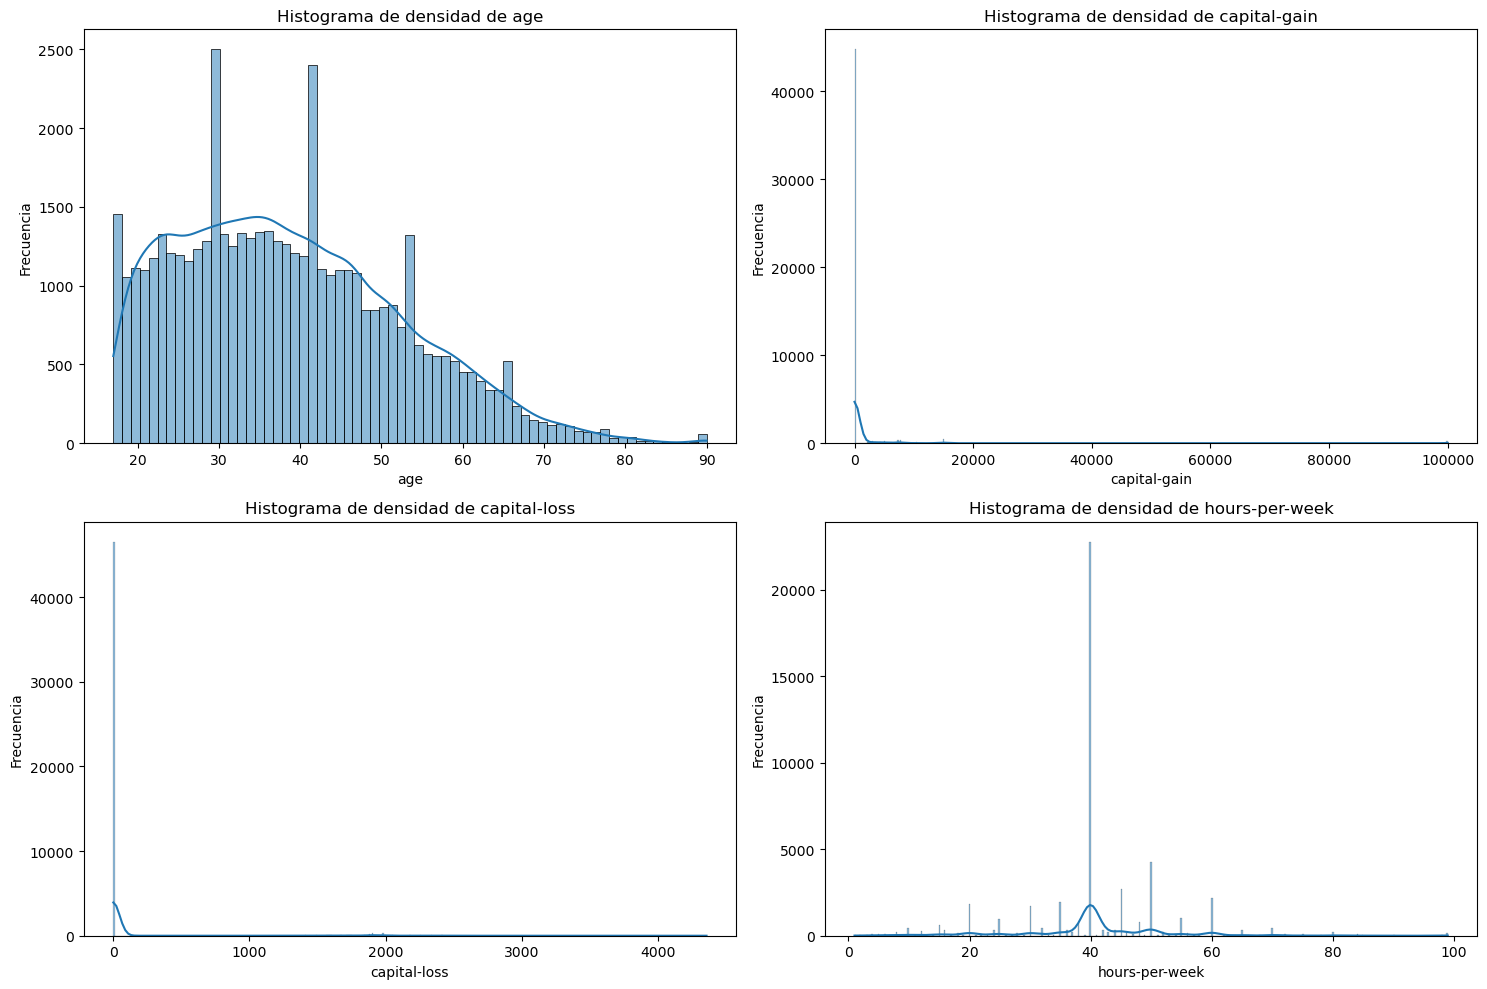

In [44]:
# Definir el número de columnas
ncols = 2
nrows = (len(df_num_high_cardinality.columns) + ncols - 1) // ncols

fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5 * nrows))

for i, column in enumerate(df_num_high_cardinality.columns):
    row = i // ncols
    col = i % ncols
    sns.histplot(df_num_high_cardinality[column], kde=True, ax=axs[row, col])
    axs[row, col].set_title(f'Histograma de densidad de {column}')
    axs[row, col].set_xlabel(column)
    axs[row, col].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [45]:
df_num_high_cardinality.quantile(0.75) - df_num_high_cardinality.quantile(0.25)

age               20.0
capital-gain       0.0
capital-loss       0.0
hours-per-week     5.0
dtype: float64

In [46]:
iqr = df_num_high_cardinality.quantile(0.75) - df_num_high_cardinality.quantile(0.25)
# aplicamos a alta cardinalidad a df_raw_num_high_cardinality

def iqr_windsorize(df, columns, iqr_threshold=1.5, windsorize_threshold=0.95):
    """
    Imputación de valores atípicos utilizando el rango intercuartílico (IQR) si el rango intercuartílico es distinto de 0.
    Si el rango intercuartílico es 0, se aplicará la windsorización a los valores superiores al percentil 95.
    :param df: DataFrame de entrada.
    :param columns: Lista de columnas a procesar.
    :return: DataFrame con los valores atípicos imputados.
    """
    for col in columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        if q1 != q3:
            iqr_value = q3 - q1
            lower_bound = q1 - iqr_threshold * iqr_value
            upper_bound = q3 + iqr_threshold * iqr_value
            df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
            df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
        else:
            # Si el rango intercuartílico es 0, aplicamos la windsorización a los valores superiores al percentil 95
            upper_bound = df[col].quantile(windsorize_threshold)
            df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
    return df

df_clean_num_high_cardinality = iqr_windsorize(df_num_high_cardinality, high_cardinality)

In [48]:
print('columnas con alta cardinalidad antes de la imputación')
df[high_cardinality].describe(percentiles=[.25, .5, .75, .9, .95, .99]).T.sort_values(by='50%', ascending=False)

columnas con alta cardinalidad antes de la imputación


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
hours-per-week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,55.0,60.0,80.0,99.0
age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,58.0,63.0,74.0,90.0
capital-gain,48842.0,1079.067626,7452.019058,0.0,0.0,0.0,0.0,0.0,5013.0,15024.0,99999.0
capital-loss,48842.0,87.502314,403.004552,0.0,0.0,0.0,0.0,0.0,0.0,2001.0,4356.0


In [49]:
print('columnas con alta cardinalidad después de la imputación')
df_num_high_cardinality.describe(percentiles=[.25, .5, .75, .9, .95, .99]).T.sort_values(by='50%', ascending=False)

columnas con alta cardinalidad después de la imputación


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
hours-per-week,48842.0,41.192805,6.184799,32.5,40.0,40.0,45.0,52.5,52.5,52.5,52.5
age,48842.0,38.618566,13.630359,17.0,28.0,37.0,48.0,58.0,63.0,74.0,78.0
capital-gain,48842.0,350.200504,1216.244535,0.0,0.0,0.0,0.0,0.0,5013.0,5013.0,5013.0
capital-loss,48842.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Parece que se han imputado todos los outliers menos el ultimo

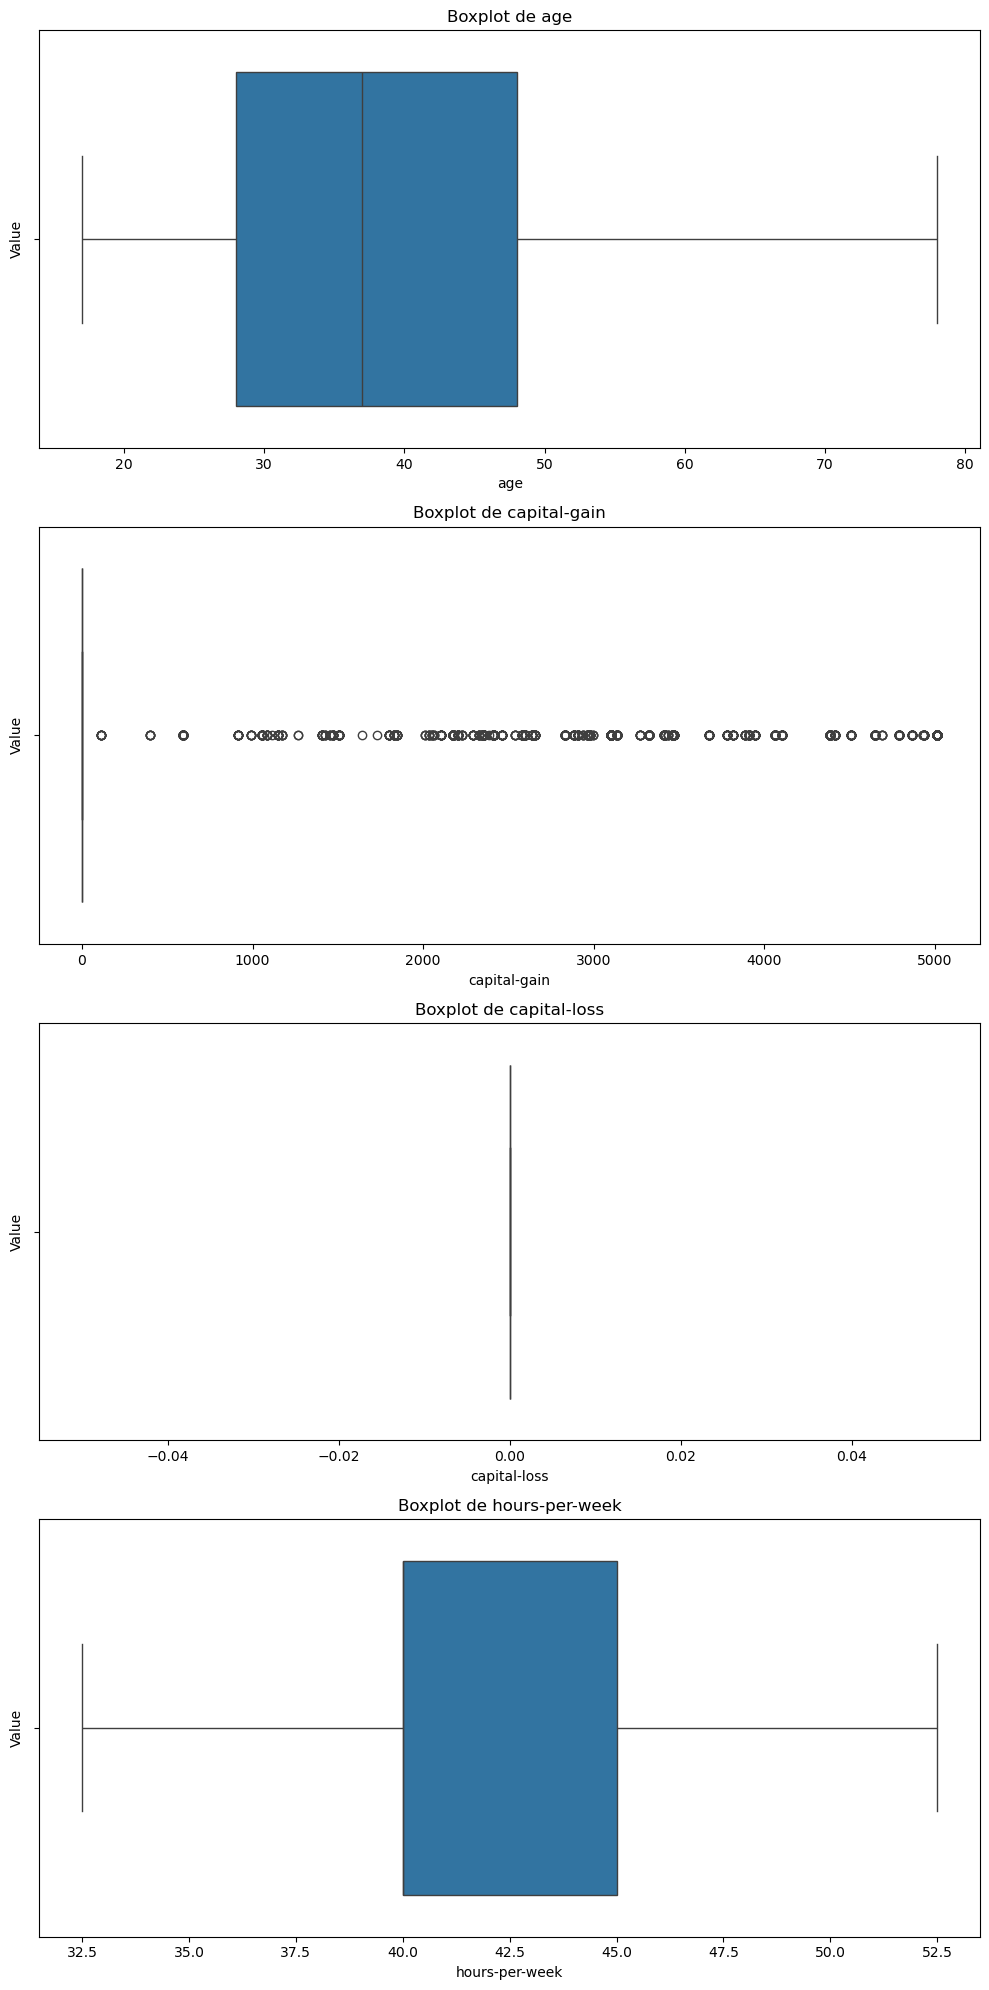

In [51]:
# boxplots 
fig, axs = plt.subplots(nrows=len(high_cardinality), ncols=1, figsize=(10, 5 * len(high_cardinality)))
for i, column in enumerate(high_cardinality):
    # Boxplot
    sns.boxplot(x=df_num_high_cardinality[column], ax=axs[i])
    axs[i].set_title(f'Boxplot de {column}')
    axs[i].set_xlabel(column)
    axs[i].set_ylabel('Value')
plt.tight_layout()
plt.show()

Como hemos visto en el analisis univariado podemos ver que las variables 'capital-gain' y 'capital-loss' tienen casi todos los registros en el 0. Al aplicar la winsorización, 'capital-loss' se reduce a 0. Y en 'capital-gain', el boxplot sigue mostrando outliers debido a que el IQR que es 0. Entonces no aplicariamos la windsorización. 

# Analisis Multivariante

In [67]:
num_cols

['age', 'capital-gain', 'capital-loss', 'hours-per-week']

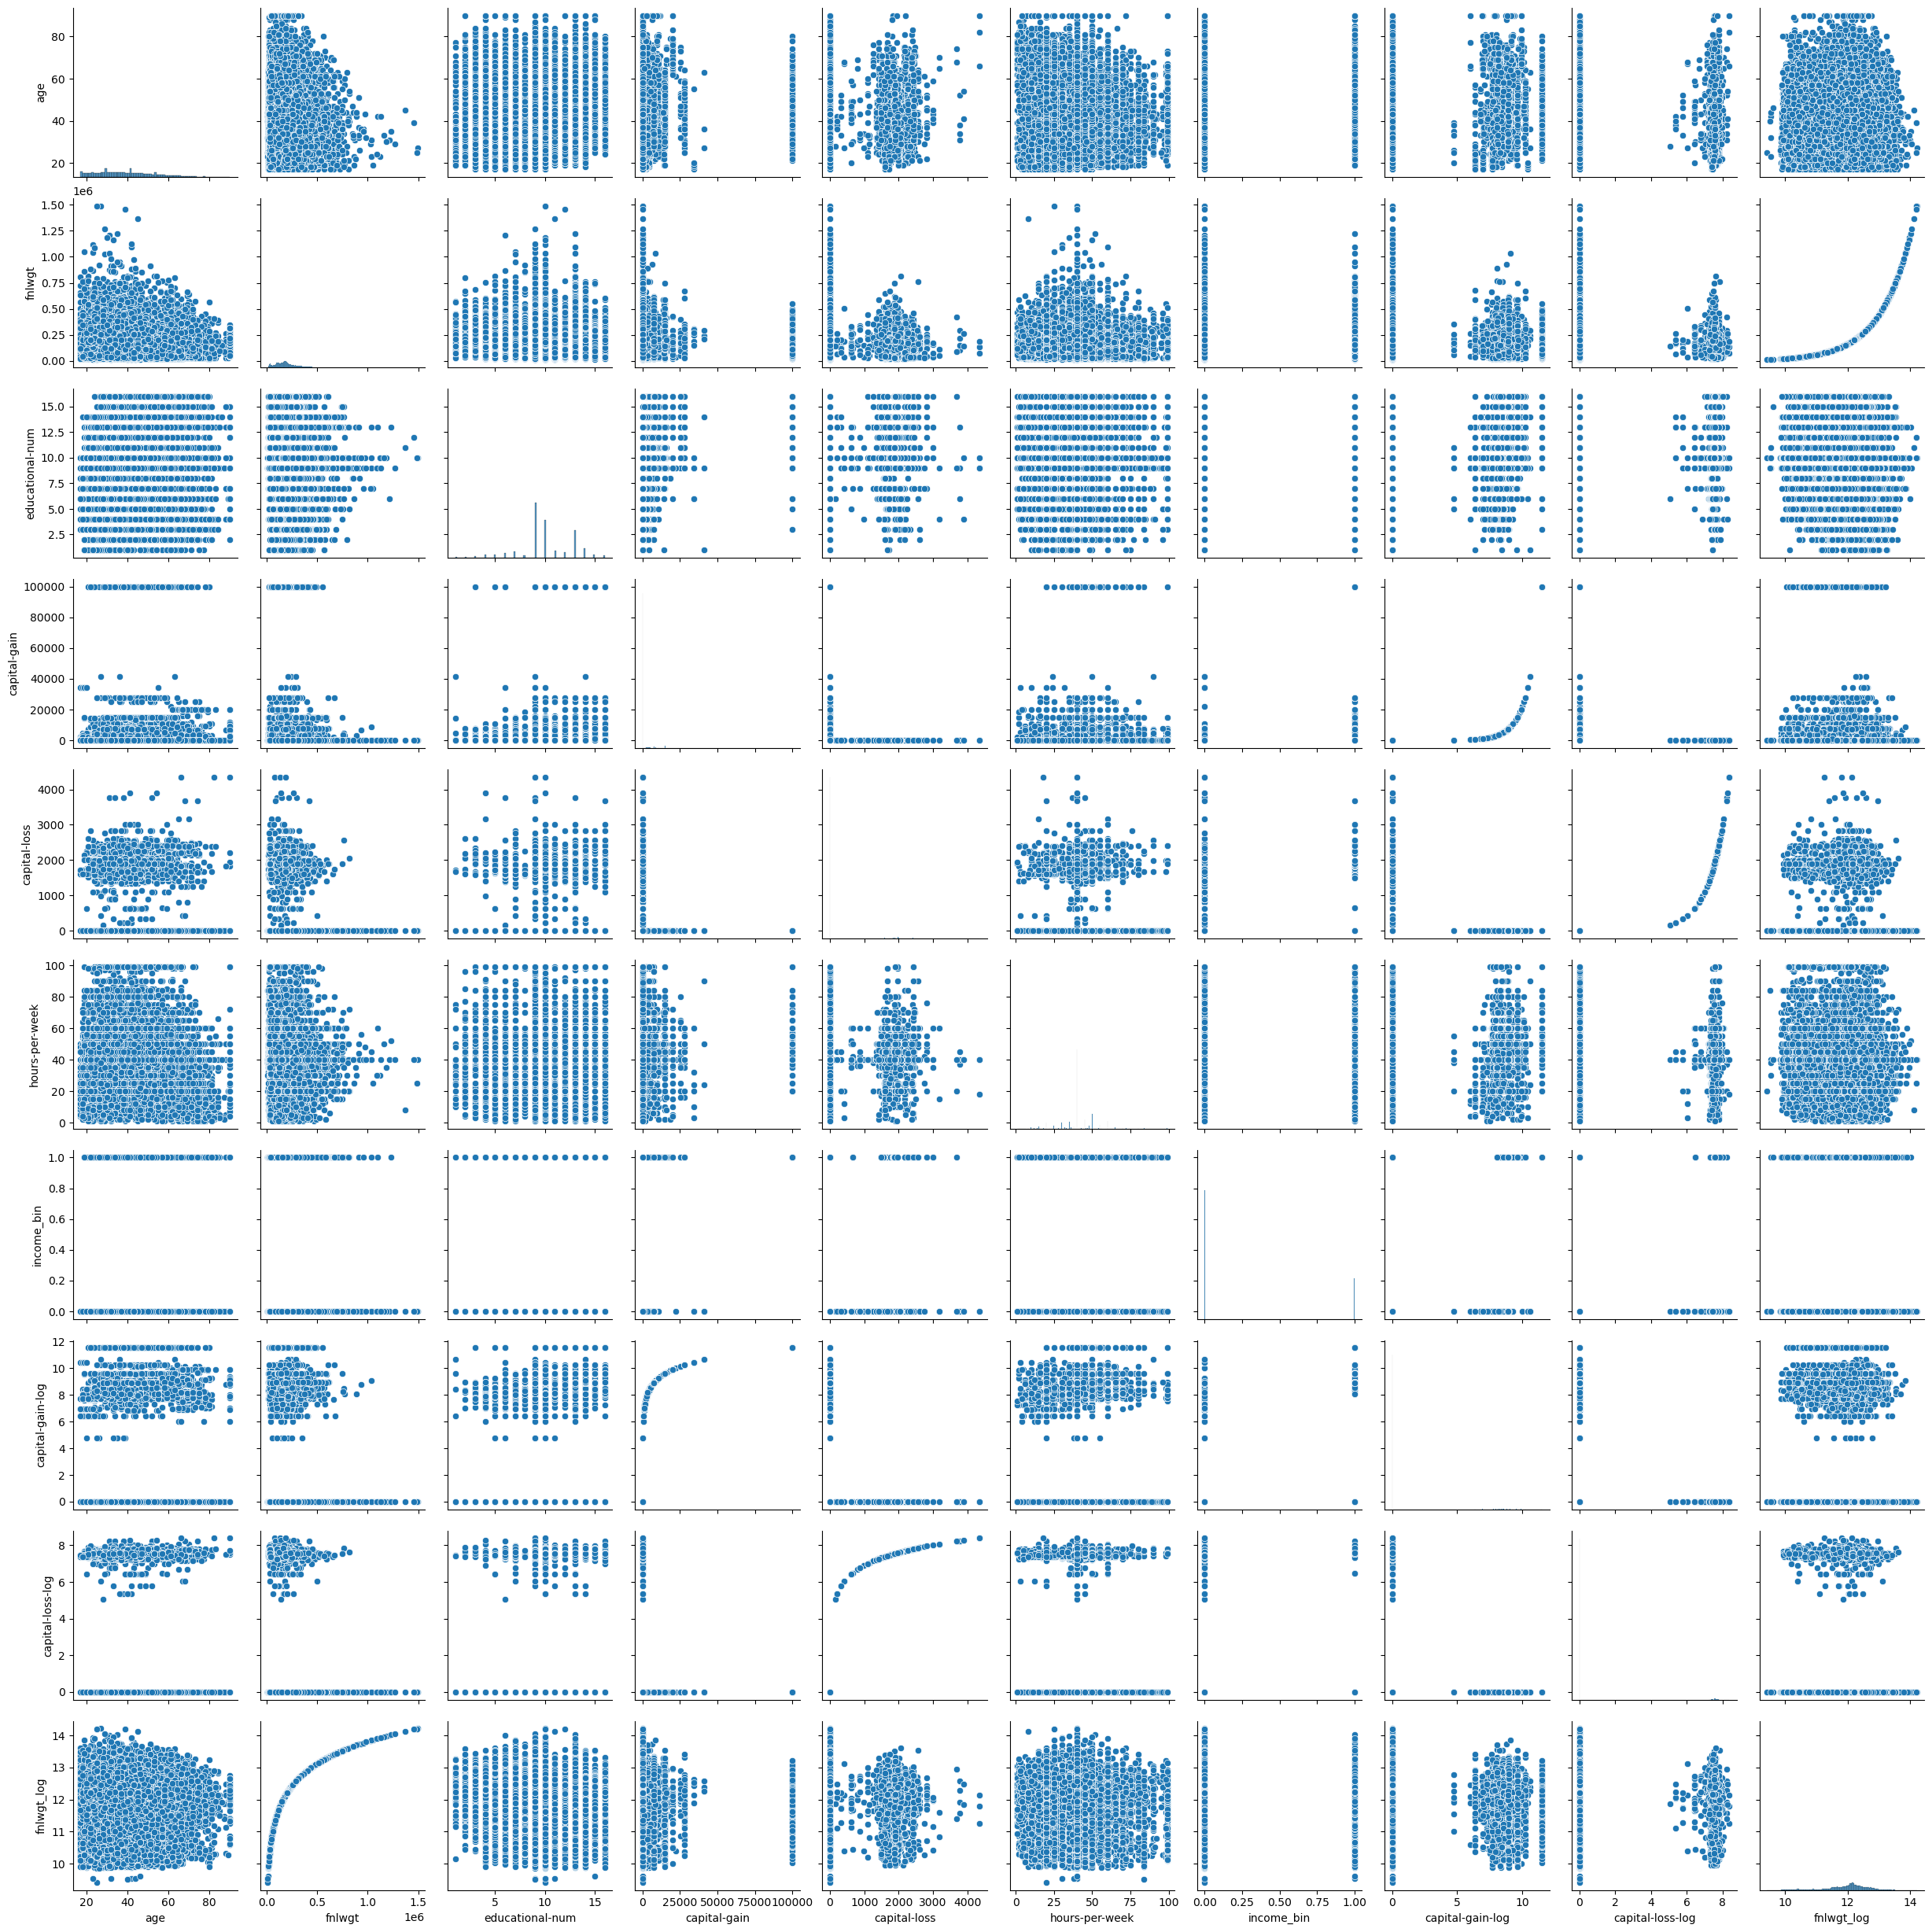

In [69]:
sns.pairplot(df);

In [70]:
# Correlaciones
df[num_columns].corr()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week,income_bin,capital-gain-log,capital-loss-log,fnlwgt_log
age,1.000000,-0.076628,0.030940,0.077229,0.056944,0.071558,0.230369,0.123892,0.051706,-0.062755
fnlwgt,-0.076628,1.000000,-0.038761,-0.003706,-0.004366,-0.013519,-0.006339,-0.007256,-0.003502,0.903612
educational-num,0.030940,-0.038761,1.000000,0.125146,0.080972,0.143689,0.332613,0.129068,0.078352,-0.033873
capital-gain,0.077229,-0.003706,0.125146,1.000000,-0.031441,0.082157,0.223013,0.563870,-0.032040,-0.001401
capital-loss,0.056944,-0.004366,0.080972,-0.031441,1.000000,0.054467,0.147554,-0.064686,0.986214,0.000616
hours-per-week,0.071558,-0.013519,0.143689,0.082157,0.054467,1.000000,0.227687,0.084471,0.051705,-0.019429
income_bin,0.230369,-0.006339,0.332613,0.223013,0.147554,0.227687,1.000000,0.289144,0.138297,0.001279
capital-gain-log,0.123892,-0.007256,0.129068,0.563870,-0.064686,0.084471,0.289144,1.000000,-0.065919,-0.004198
capital-loss-log,0.051706,-0.003502,0.078352,-0.032040,0.986214,0.051705,0.138297,-0.065919,1.000000,0.001360
fnlwgt_log,-0.062755,0.903612,-0.033873,-0.001401,0.000616,-0.019429,0.001279,-0.004198,0.001360,1.000000


In [71]:
# Defino un cmap para ver más claramente los colores
cmap = sns.diverging_palette(500, 10, as_cmap=True)

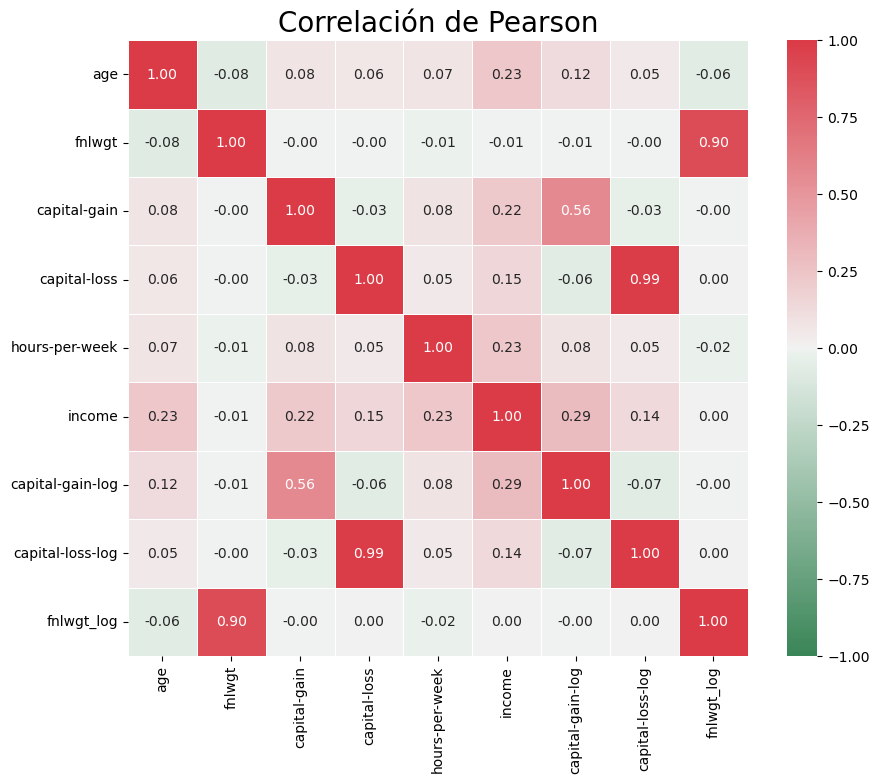

In [ ]:
# El principio con IA, porque no me aparecia income, si no que me aparecia income_bin que es la que utilizamos para las hipotesis
# Creamos copia temporal con income numérico para la gráfica
df_temp = df.copy()
df_temp['income'] = (df_temp['income'] == '>50K').astype(int)

# Definimos la lista
num_columns = ['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week', 'income', 'capital-gain-log', 'capital-loss-log', 'fnlwgt_log']

plt.figure(figsize=(10,8))
sns.heatmap(df_temp[num_columns].corr(method='pearson'),
            annot=True, 
            fmt=".2f", linewidths=.5, cmap=cmap, vmin=-1, vmax=1)
plt.title("Correlación de Pearson", fontsize=20)
plt.show()

Podemos ver que no hay multicolinealidad, porque la mayoria se acercan a 0.
Tambien podemos ver que ninguna tiene una correlacion muy fuerte con la target. 
Podemos eliminar la variable de fnlwgt

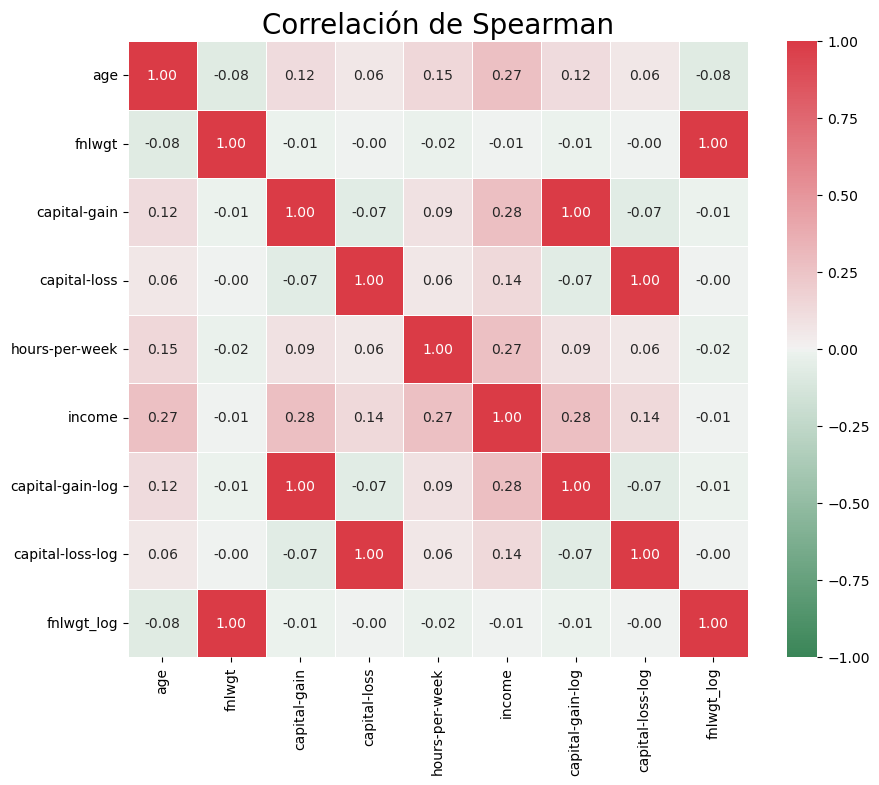

In [86]:
# Definimos la lista
num_columns = ['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week', 'income', 'capital-gain-log', 'capital-loss-log', 'fnlwgt_log']

plt.figure(figsize=(10,8))
sns.heatmap(df_temp[num_columns].corr(method='spearman'),
            annot=True, 
            fmt=".2f", linewidths=.5, cmap=cmap, vmin=-1, vmax=1)
plt.title("Correlación de Spearman", fontsize=20)
plt.show()

Las de spearman son un poco mas altas, pero se puede ver lo mismo que en la de pearson

Pusimos las variables que hemos creado con los logaritmos, para ver si mejoraba algo la correlacion, pero podemos ver que no

# Conclusiones del EDA